In [38]:
import pandas as pd

In [39]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [40]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

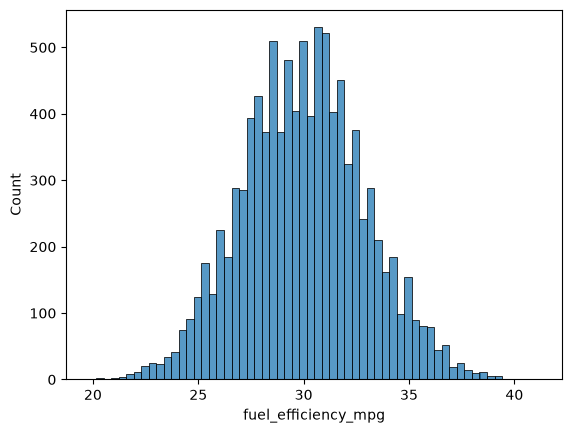

In [42]:
sns.histplot(df.fuel_efficiency_mpg)

In [43]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [44]:
df.horsepower.median()

np.float64(254.0)

In [45]:
import numpy as np

In [46]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [47]:
df_0_filled = df.copy(deep=True)
df_0_filled.horsepower = df_0_filled.horsepower.fillna(0)

In [48]:
df_0_filled.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [49]:
df_0_filled

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [50]:
df_train = df_0_filled.iloc[idx[:n_train]]
df_val = df_0_filled.iloc[idx[n_train:n_train + n_val]]
df_test = df_0_filled.iloc[idx[n_train + n_val:]]

In [51]:
df_test.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [52]:
X_0_train = df_train[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
X_0_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [53]:
y_0_train = df_train.fuel_efficiency_mpg

In [54]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,0.0,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,0.0,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [55]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full

In [56]:
w_full = train_linear_regression(X_0_train, y_0_train)
w_full

array([-1.53884962e+02, -1.51505520e-03, -4.74024794e-06, -3.95418397e-03,
        1.02146785e-01])

In [57]:
X_0_val = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
X_0_val

array([[2240.,  265., 3990., 2004.],
       [2390.,  259., 4770., 2019.],
       [2360.,  265., 4320., 2018.],
       ...,
       [2390.,  264., 4550., 2017.],
       [2330.,  244., 4440., 2014.],
       [2170.,  260., 4460., 2021.]], shape=(2000, 4))

In [58]:
y_0_val = df_val.fuel_efficiency_mpg
y_0_val

2480    30.4
289     32.8
6086    27.8
3075    28.6
8123    31.1
        ... 
1638    30.3
5891    28.7
7427    30.6
608     31.0
6907    30.8
Name: fuel_efficiency_mpg, Length: 2000, dtype: float64

In [59]:
y_0_pred = w_full[0] + X_0_val.dot(w_full[1:])
y_0_pred

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [60]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [61]:
score = rmse(y_0_val, y_0_pred)
round(score, 3)

np.float64(2.205)

In [62]:
df_mean_filled = df.copy(deep=True)
df_mean_filled.horsepower = df_mean_filled.horsepower.fillna(df_train.horsepower.mean())

In [63]:
df_train = df_mean_filled.iloc[idx[:n_train]]
df_val = df_mean_filled.iloc[idx[n_train:n_train + n_val]]
df_test = df_mean_filled.iloc[idx[n_train + n_val:]]

In [64]:
df_train.horsepower.mean()

np.float64(252.41746949999998)

In [65]:
X_mean_train = df_train[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
X_mean_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [66]:
y_mean_train = df_train.fuel_efficiency_mpg

In [67]:
w_full = train_linear_regression(X_mean_train, y_mean_train)
w_full

array([-1.55042080e+02, -1.13753578e-03, -5.01167317e-03, -3.89979714e-03,
        1.02812860e-01])

In [68]:
X_mean_val = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
y_mean_val = df_val.fuel_efficiency_mpg

In [69]:
y_mean_pred = w_full[0] + X_mean_val.dot(w_full[1:])

In [70]:
score = rmse(y_mean_val, y_mean_pred)
round(score, 3)

np.float64(2.201)

In [71]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full

In [80]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_full = train_linear_regression_reg(X_0_train, y_0_train, r)
    y_0_pred = w_full[0] + X_mean_val.dot(w_full[1:])
    score = rmse(y_0_val, y_0_pred)
    print (f'r={r}, score={round(score, 4)}')

r=0, score=2.2053
r=0.01, score=2.2053
r=0.1, score=2.2219
r=1, score=2.3543
r=5, score=2.4194
r=10, score=2.4303
r=100, score=2.4409


In [73]:
y_0_pred = w_full[0] + X_mean_val.dot(w_full[1:])

In [74]:
score = rmse(y_mean_val, y_mean_pred)
round(score, 4)

np.float64(2.2012)

In [89]:
scores = []

for s in range(10):
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df_0_filled.iloc[idx[:n_train]]
    df_val = df_0_filled.iloc[idx[n_train:n_train + n_val]]
    df_test = df_0_filled.iloc[idx[n_train + n_val:]]
    X_0_train = df_train[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
    y_0_train = df_train.fuel_efficiency_mpg
    w_full = train_linear_regression(X_0_train, y_0_train)
    X_0_val = df_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values    
    y_0_val = df_val.fuel_efficiency_mpg
    y_0_pred = w_full[0] + X_0_val.dot(w_full[1:])
    score = rmse(y_0_val, y_0_pred)
    print(f'seed={s}, score={score}')
    scores.append(score)

print()
print(f'score={scores}')
print(round(np.std(scores),3))



seed=0, score=2.2392041430461465
seed=1, score=2.2021128210838907
seed=2, score=2.163419778753095
seed=3, score=2.2043588768539144
seed=4, score=2.2018800943312926
seed=5, score=2.2457851509084974
seed=6, score=2.269721207952404
seed=7, score=2.190794599933433
seed=8, score=2.2166112016864443
seed=9, score=2.207036592817851

score=[np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
0.029


In [92]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df_0_filled.iloc[idx[:n_train]]
df_val = df_0_filled.iloc[idx[n_train:n_train + n_val]]
df_test = df_0_filled.iloc[idx[n_train + n_val:]]
df_train_val = pd.concat([df_train, df_val], ignore_index=True)
X_0_train = df_train_val[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
y_0_train = df_train_val.fuel_efficiency_mpg
w_full = train_linear_regression_reg(X_0_train, y_0_train, 0.001)
X_0_test = df_test[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values    
y_0_test = df_test.fuel_efficiency_mpg
y_0_pred = w_full[0] + X_0_test.dot(w_full[1:])
score = rmse(y_0_test, y_0_pred)
round(score, 3)

np.float64(2.236)

In [91]:
pd.concat([df_train, df_val], ignore_index=True)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,0.0,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2
